# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [417]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

# Example:
# import pandas as pd

# TODO: Download any required NLTK resources.

# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...

# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows

# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer

# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens

# def preprocess_text(text):
#     pass

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

# TODO: Combine all tokens into one list so you can compute word frequencies.

# TODO: Use Counter to identify the most common words.

# TODO: Generate bigrams from the token list and identify the most common bigrams.

# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?


In [418]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.util import bigrams

In [419]:
# TODO: Download any required NLTK resources

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [420]:
# TODO: Load the dataset.
df = pd.read_csv('amazon_reviews_lab.csv')


In [421]:
# TODO: Explore the dataset.
df.shape

(997, 9)

In [422]:
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB


In [424]:
# Rating column value counts
df['rating'].value_counts()

rating
5    580
4    188
3     94
1     87
2     48
Name: count, dtype: int64

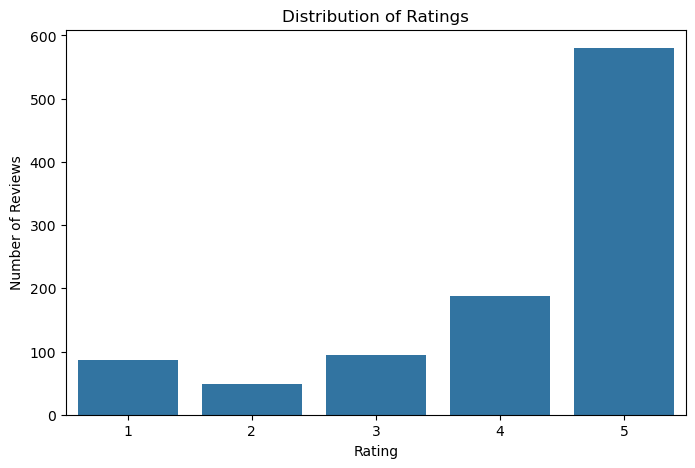

In [425]:
# Visulaize ratings
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='rating')

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

### NLP Data Quality Checks

Before further analysis, I check for missing reviews, duplicate reviews, and review-length distributions. These checks help ensure that the preprocessing pipeline is applied to valid and consistent text data.

In [426]:
print("Missing review texts:", df['review_text'].isna().sum())
print("Duplicate review texts:", df['review_text'].duplicated().sum())

print("\nReview text data type:")
print(df['review_text'].dtype)

Missing review texts: 0
Duplicate review texts: 0

Review text data type:
object


In [427]:
#reviews length analysis

df['raw_word_count'] = df['review_text'].str.split().str.len()

df['raw_word_count'].describe()

count     997.000000
mean      146.374122
std       216.126770
min         5.000000
25%        32.000000
50%        67.000000
75%       165.000000
max      2079.000000
Name: raw_word_count, dtype: float64

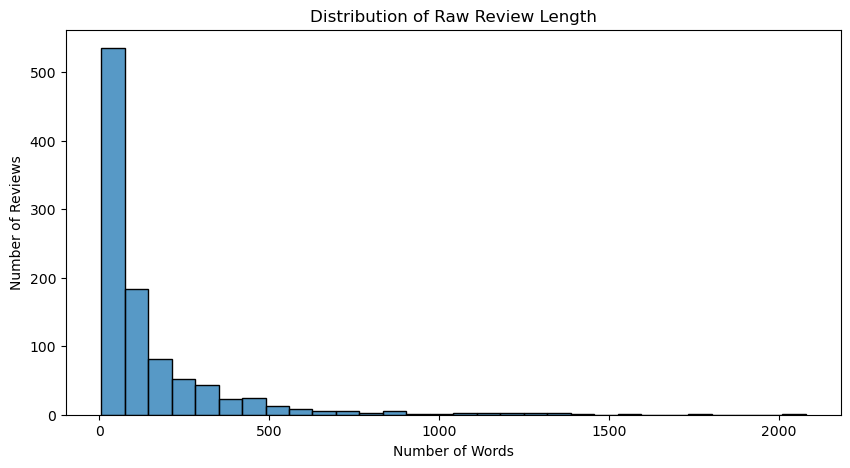

In [428]:
#visualize
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='raw_word_count',
    bins=30
)

plt.title('Distribution of Raw Review Length')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

plt.show()

In [429]:
# TODO: Create preprocessing tools such as

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [430]:
# preprocessing function

def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    #Tokenize the text
    tokens = word_tokenize(text)
    
    # Keep alphabetic tokens only
    tokens = [word for word in tokens if word.isalpha()]
    
    #Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    #Lemmatize words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    #Return cleaned tokens
    return tokens

In [431]:
# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

df['processed_tokens'] = df['review_text'].apply(preprocess_text)

In [432]:
df['processed_word_count'] = df['processed_tokens'].apply(len)

comparison = df[
    ['raw_word_count', 'processed_word_count']
]

comparison.describe()


,raw_word_count,processed_word_count
count,997.000000,997.000000
mean,146.374122,73.011033
std,216.126770,108.998549
min,5.000000,3.000000
25%,32.000000,15.000000
50%,67.000000,31.000000
75%,165.000000,82.000000
max,2079.000000,1066.000000




The processed reviews contain fewer tokens than the original reviews because punctuation, URLs, stopwords, and non-alphabetic tokens were removed. 

In [433]:
# TODO: Combine all tokens into one list so you can compute word frequencies.

all_tokens = [
    token
    for tokens in df['processed_tokens']
    for token in tokens
]

len(all_tokens)

72792

In [434]:
# TODO: Use Counter to identify the most common words

word_counts = Counter(all_tokens)

word_counts.most_common(20)

[('nook', 1516),
 ('book', 914),
 ('one', 569),
 ('kindle', 566),
 ('screen', 498),
 ('like', 460),
 ('read', 454),
 ('work', 447),
 ('get', 424),
 ('great', 422),
 ('use', 421),
 ('tablet', 421),
 ('tv', 416),
 ('device', 381),
 ('would', 378),
 ('good', 333),
 ('bn', 321),
 ('time', 319),
 ('also', 317),
 ('well', 306)]

In [435]:

# TODO: Generate bigrams from the token list and identify the most common bigrams.

all_bigrams = []

for tokens in df['processed_tokens']:
    all_bigrams.extend(bigrams(tokens))


all_bigrams[:20]


[('film', 'definitely'),
 ('definitely', 'anyone'),
 ('anyone', 'especially'),
 ('especially', 'fond'),
 ('fond', 'independent'),
 ('independent', 'delightfully'),
 ('delightfully', 'manipulative'),
 ('manipulative', 'clever'),
 ('clever', 'boy'),
 ('boy', 'brain'),
 ('brain', 'child'),
 ('child', 'samuel'),
 ('samuel', 'clemens'),
 ('clemens', 'classicas'),
 ('classicas', 'one'),
 ('one', 'example'),
 ('example', 'book'),
 ('book', 'great'),
 ('great', 'fun'),
 ('fun', 'scene')]

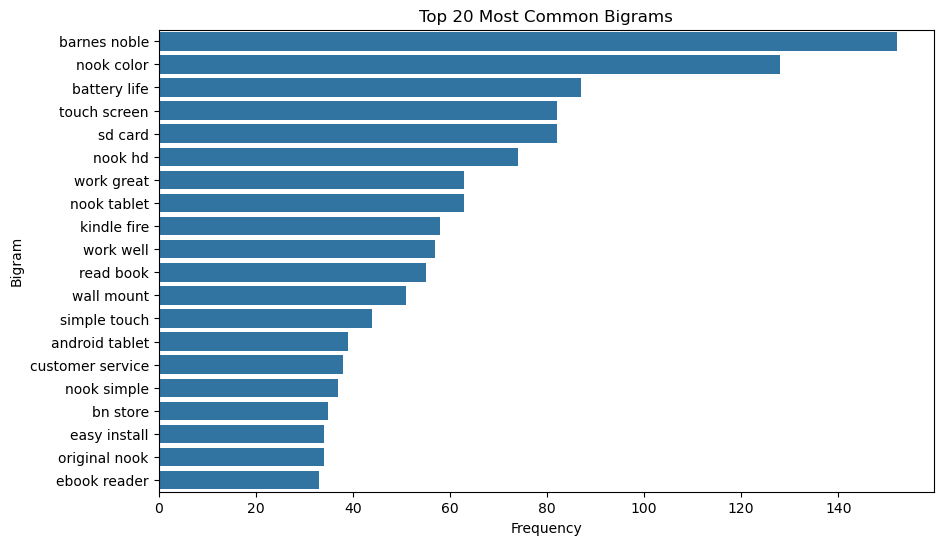

In [436]:
# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.


bigram_counts = Counter(all_bigrams)

bigram_counts.most_common(20)

common_bigrams = pd.DataFrame(
    [
        (' '.join(bigram), count)
        for bigram, count in bigram_counts.most_common(20)
    ],
    columns=['bigram', 'frequency']
)

common_bigrams

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_bigrams,
    x='frequency',
    y='bigram'
)

plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

plt.show()

In [437]:
#Analyze positive vs negative language

df['sentiment_label'].value_counts()

sentiment_label
positive    768
negative    135
neutral      94
Name: count, dtype: int64

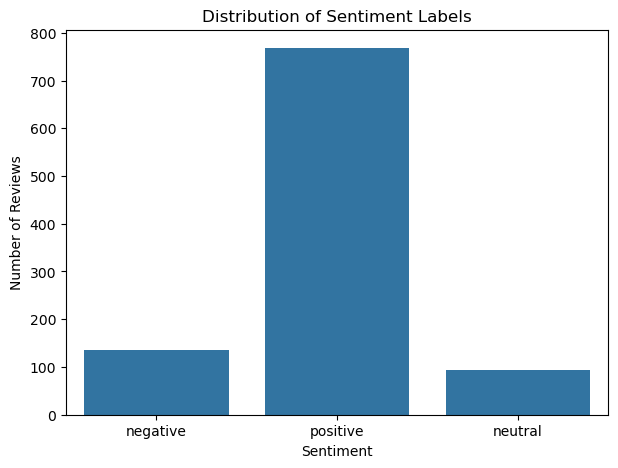

In [438]:
#Visulaize
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='sentiment_label'
)

plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

### Reflection prompt:
#### What do the most common words or phrases suggest about customer sentiment or product experience?

The most common bigrams reveal that customers frequently discuss specific products and features, particularly barnes and nook devices. Phrases such as "nook color", "nook HD", and "Kindle Fire" indicate that product models and competing devices are common topics. Also there are feature related phrases such as "battery life", "touch screen", and "SD card" suggest that customers are concerned with device performance and functionality. Positive phrases such as "work great", "work well", and "easy install" indicate generally positive experiences with product performance and usability. Overall, the bigram analysis suggests that product functionality, device features, and customer experience are major themes in the reviews.


## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [439]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need.

# TODO: Load the same review dataset.
# df = ...

# TODO: Convert the timestamp column to datetime format.

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

# TODO: Plot monthly review volume over time.

# TODO: Plot average monthly rating over time.

# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


In [440]:
#Time Series Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [441]:
# TODO: Load the same review dataset

df = pd.read_csv('amazon_reviews_lab.csv')

df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [442]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB


In [443]:
# Check for missing values

print("Missing timestamps:", df['timestamp'].isna().sum())
print("Missing ratings:", df['rating'].isna().sum())

Missing timestamps: 0
Missing ratings: 0


In [444]:
# TODO: Convert the timestamp column to datetime format..

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].dtype


dtype('<M8[ns]')

In [445]:
# TODO: Inspect the date range in the dataset.

earliest_date = df['timestamp'].min()
latest_date = df['timestamp'].max()

print("Earliest timestamp:", earliest_date)
print("Latest timestamp:", latest_date)


Earliest timestamp: 2000-05-12 00:00:00
Latest timestamp: 2014-07-17 00:00:00


In [446]:
#Set timestamp as the index
df = df.set_index('timestamp')
df = df.sort_index()


In [447]:
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,sentiment_label,review_length_words
timestamp,,,,,,,,
2000-05-12,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,negative,302
2002-08-26,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,positive,168
2005-08-06,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,negative,60
2005-09-11,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,negative,104
2007-10-15,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,positive,60


In [448]:
# TODO: Resample the data by month to calculate:
# 1. monthly review count
monthly_review_count = df['rating'].resample('MS').count()

monthly_review_count.head()


timestamp
2000-05-01    1
2000-06-01    0
2000-07-01    0
2000-08-01    0
2000-09-01    0
Freq: MS, Name: rating, dtype: int64

In [449]:
# 2. monthly average rating

monthly_avg_rating = df['rating'].resample('MS').mean()

monthly_avg_rating.head()

timestamp
2000-05-01    2.0
2000-06-01    NaN
2000-07-01    NaN
2000-08-01    NaN
2000-09-01    NaN
Freq: MS, Name: rating, dtype: float64

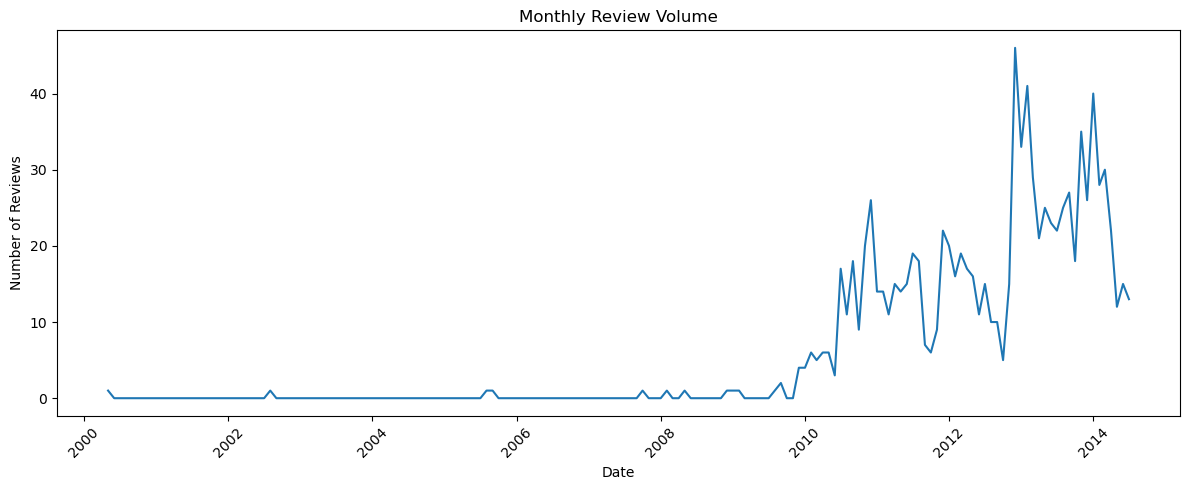

In [450]:
# TODO: Plot monthly review volume over time.

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_review_count.index,
    monthly_review_count.values
)

plt.title('Monthly Review Volume')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

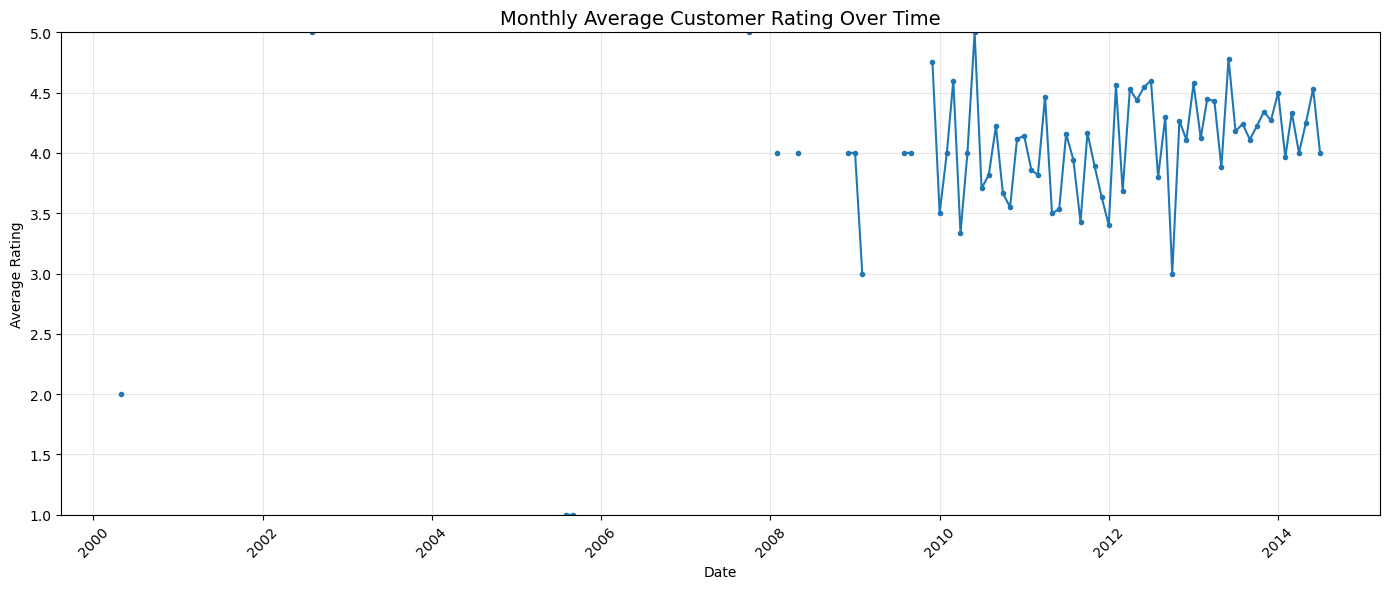

In [451]:
# TODO: Plot average monthly rating over time

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_avg_rating.index,
    monthly_avg_rating.values,
    marker='o',
    markersize=3,
    linewidth=1.5
)

plt.title('Monthly Average Customer Rating Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Rating')

plt.ylim(1, 5)

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Compute a rolling average for the monthly average rating.

rolling_avg_rating = monthly_avg_rating.rolling(window=3).mean()

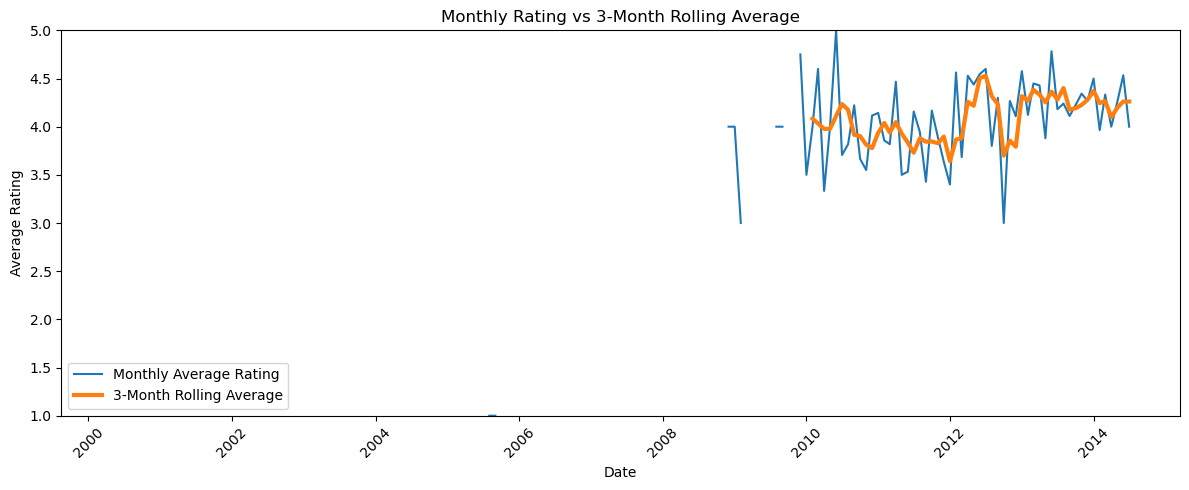

In [453]:
# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg_rating.index,
    monthly_avg_rating.values,
    label='Monthly Average Rating'
)

plt.plot(
    rolling_avg_rating.index,
    rolling_avg_rating.values,
    label='3-Month Rolling Average',
    linewidth=3
)

plt.title('Monthly Rating vs 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Average Rating')

plt.ylim(1, 5)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Reflection prompt:
#### What overall trends do you notice in review activity and customer ratings over time?

The review activity is relatively low  during the earlier years, but it increases substantially in the later years, particularly from around 2010 onward. This indicates growing review activity over time. The monthly average ratings fluctuate between approximately 3 and 5 stars, with some months showing noticeable variation. However, months with very few reviews can produce unstable averages because they are based on limited observations. The 3-month rolling average smooths out some of these short-term fluctuations and provides a clearer view of the underlying rating trend. Overall, customer ratings appear generally positive in the later period, while review volume shows a much stronger upward trend.

In [454]:
# Test for stationarity using ADF test

stationarity_series = monthly_avg_rating.dropna()

adf_result = adfuller(stationarity_series)

adf_statistic = adf_result[0]
p_value = adf_result[1]

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: The series is stationary.")
else:
    print("Conclusion: The series is not stationary.")

ADF Statistic: -1.455688466907747
p-value: 0.5553067746051625
Conclusion: The series is not stationary.


p-value of 0.5553, the p-value is greater than the 0.05 significance level, we fail to reject the null hypothesis that the series is non-stationary.

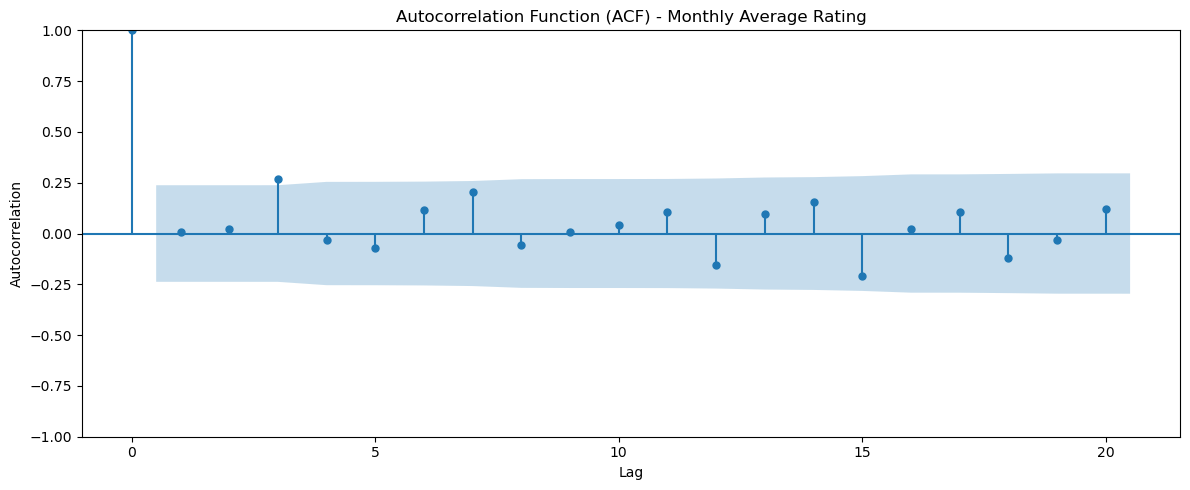

In [455]:
# ACF of the monthly average rating

observed_monthly_rating = monthly_avg_rating.dropna()

plt.figure(figsize=(12, 5))

plot_acf(
    observed_monthly_rating,
    lags=20,
    ax=plt.gca()
)

plt.title('Autocorrelation Function (ACF) - Monthly Average Rating')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

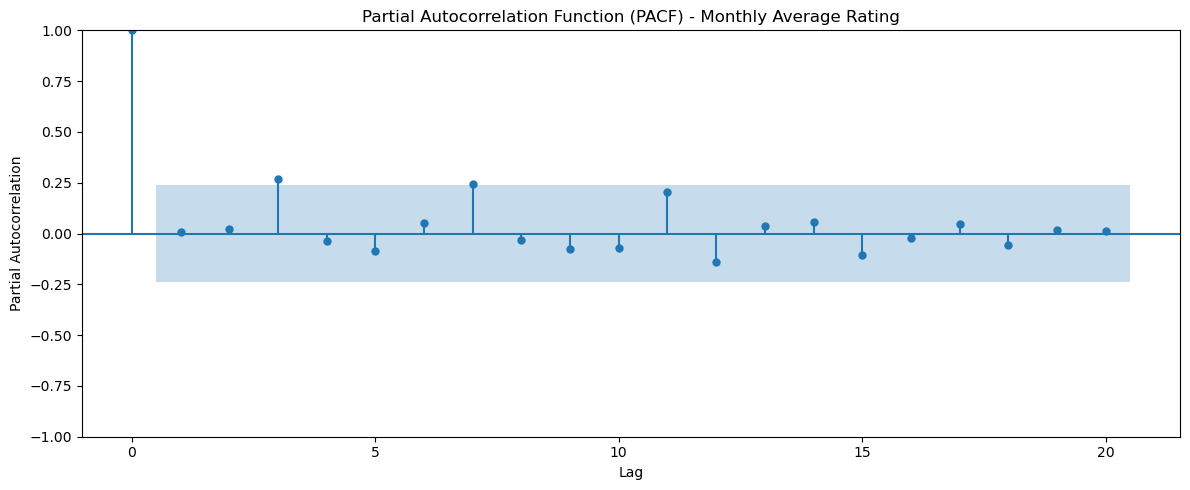

In [456]:
# PACF of the monthly average rating

plt.figure(figsize=(12, 5))

plot_pacf(
    observed_monthly_rating,
    lags=20,
    ax=plt.gca(),
    method='ywm'
)

plt.title('Partial Autocorrelation Function (PACF) - Monthly Average Rating')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

In [457]:
#first order differencing


differenced_rating = observed_monthly_rating.diff().dropna()

print("Original observations:", len(observed_monthly_rating))
print("Differenced observations:", len(differenced_rating))

differenced_rating.head()

Original observations: 68
Differenced observations: 67


timestamp
2002-08-01    3.0
2005-08-01   -4.0
2005-09-01    0.0
2007-10-01    4.0
2008-02-01   -1.0
Name: rating, dtype: float64

In [458]:
#running the ADF test again after differencing to check for stationarity


adf_diff_result = adfuller(differenced_rating)

adf_diff_statistic = adf_diff_result[0]
adf_diff_pvalue = adf_diff_result[1]

print("ADF Statistic after differencing:", adf_diff_statistic)
print("p-value after differencing:", adf_diff_pvalue)

if adf_diff_pvalue < 0.05:
    print("Conclusion: The differenced series is stationary.")
else:
    print("Conclusion: The differenced series is still not stationary.")

ADF Statistic after differencing: -5.464464508721831
p-value after differencing: 2.4766068541947217e-06
Conclusion: The differenced series is stationary.


The original monthly average rating was non-stationary, but after first-order differencing, the series became stationary.

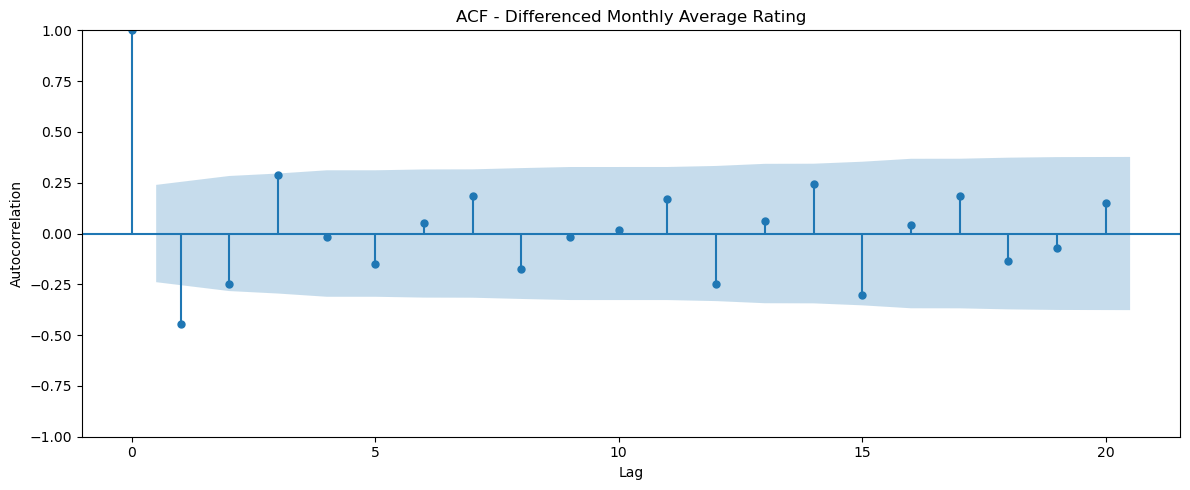

In [459]:
# ACF of the differenced rating series

plt.figure(figsize=(12, 5))

plot_acf(
    differenced_rating,
    lags=20,
    ax=plt.gca()
)

plt.title('ACF - Differenced Monthly Average Rating')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

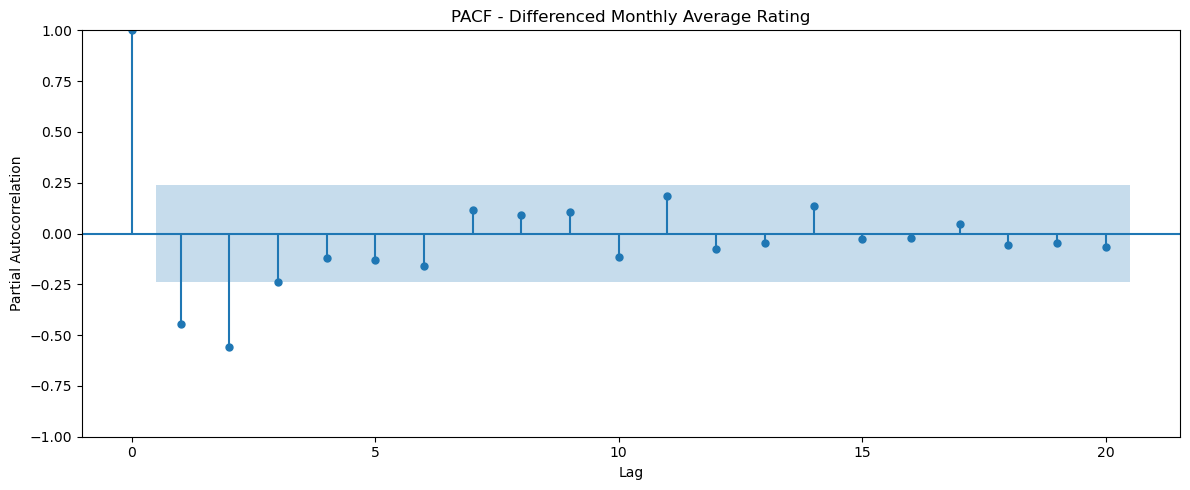

In [460]:
# PACF of the differenced rating series

plt.figure(figsize=(12, 5))

plot_pacf(
    differenced_rating,
    lags=20,
    ax=plt.gca(),
    method='ywm'
)

plt.title('PACF - Differenced Monthly Average Rating')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

In [461]:
#train-test split

series = observed_monthly_rating.copy()

split_point = int(len(series) * 0.80)

train = series.iloc[:split_point]
test = series.iloc[split_point:]

print("Total observations:", len(series))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Total observations: 68
Training observations: 54
Testing observations: 14

Training period:
2000-05-01 00:00:00 to 2013-05-01 00:00:00

Testing period:
2013-06-01 00:00:00 to 2014-07-01 00:00:00


In [462]:
# AutoReg model

autoreg_model = AutoReg(
    train,
    lags=3,
    trend='c'
).fit()

print(autoreg_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                 rating   No. Observations:                   54
Model:                     AutoReg(3)   Log Likelihood                 -40.970
Method:               Conditional MLE   S.D. of innovations              0.540
Date:                Sun, 13 Sep 2026   AIC                             91.939
Time:                        20:47:45   BIC                            101.599
Sample:                             3   HQIC                            95.631
                                   54                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1592      0.678      4.658      0.000       1.830       4.489
rating.L1      0.1838      0.103      1.793      0.073      -0.017       0.385
rating.L2     -0.2248      0.101     -2.228      0.0

c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [463]:
# AutoReg predictions on the test set

autoreg_pred = autoreg_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

# Evaluate AutoReg
autoreg_mae = mean_absolute_error(test, autoreg_pred)
autoreg_mse = mean_squared_error(test, autoreg_pred)
autoreg_rmse = np.sqrt(autoreg_mse)

print("AutoReg Results")
print("----------------")
print(f"MAE:  {autoreg_mae:.4f}")
print(f"MSE:  {autoreg_mse:.4f}")
print(f"RMSE: {autoreg_rmse:.4f}")
print(f"AIC:  {autoreg_model.aic:.4f}")
print(f"BIC:  {autoreg_model.bic:.4f}")

AutoReg Results
----------------
MAE:  0.2633
MSE:  0.1169
RMSE: 0.3419
AIC:  91.9395
BIC:  101.5986


c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [464]:
# ARIMA model

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
).fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 rating   No. Observations:                   54
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -63.053
Date:                Sun, 13 Sep 2026   AIC                            132.106
Time:                        20:47:45   BIC                            138.016
Sample:                             0   HQIC                           134.379
                                 - 54                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1211      0.093     -1.305      0.192      -0.303       0.061
ma.L1         -0.8579      0.124     -6.929      0.000      -1.101      -0.615
sigma2         0.6141      0.102      6.016      0.0

c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [465]:
# ARIMA predictions

arima_pred = arima_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)


arima_pred.index = test.index

# Evaluate ARIMA
arima_mae = mean_absolute_error(test, arima_pred)
arima_mse = mean_squared_error(test, arima_pred)
arima_rmse = np.sqrt(arima_mse)

print("ARIMA(1,1,1) Results")
print("--------------------")
print(f"MAE:  {arima_mae:.4f}")
print(f"MSE:  {arima_mse:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"AIC:  {arima_model.aic:.4f}")
print(f"BIC:  {arima_model.bic:.4f}")

ARIMA(1,1,1) Results
--------------------
MAE:  0.1855
MSE:  0.0565
RMSE: 0.2378
AIC:  132.1056
BIC:  138.0165


c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\anaconda3\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [466]:
# Compare AutoReg and ARIMA models

model_comparison = pd.DataFrame({
    'Model': ['AutoReg(3)', 'ARIMA(1,1,1)'],
    'MAE': [autoreg_mae, arima_mae],
    'MSE': [autoreg_mse, arima_mse],
    'RMSE': [autoreg_rmse, arima_rmse],
    'AIC': [autoreg_model.aic, arima_model.aic],
    'BIC': [autoreg_model.bic, arima_model.bic]
})

model_comparison

,Model,MAE,MSE,RMSE,AIC,BIC
0,AutoReg(3),0.263260,0.116897,0.341902,91.939483,101.598611
1,"ARIMA(1,1,1)",0.185479,0.056527,0.237754,132.105605,138.016480


ARIMA(1,1,1) has the better forecasting performance because it has the lower MAE and RMSE.

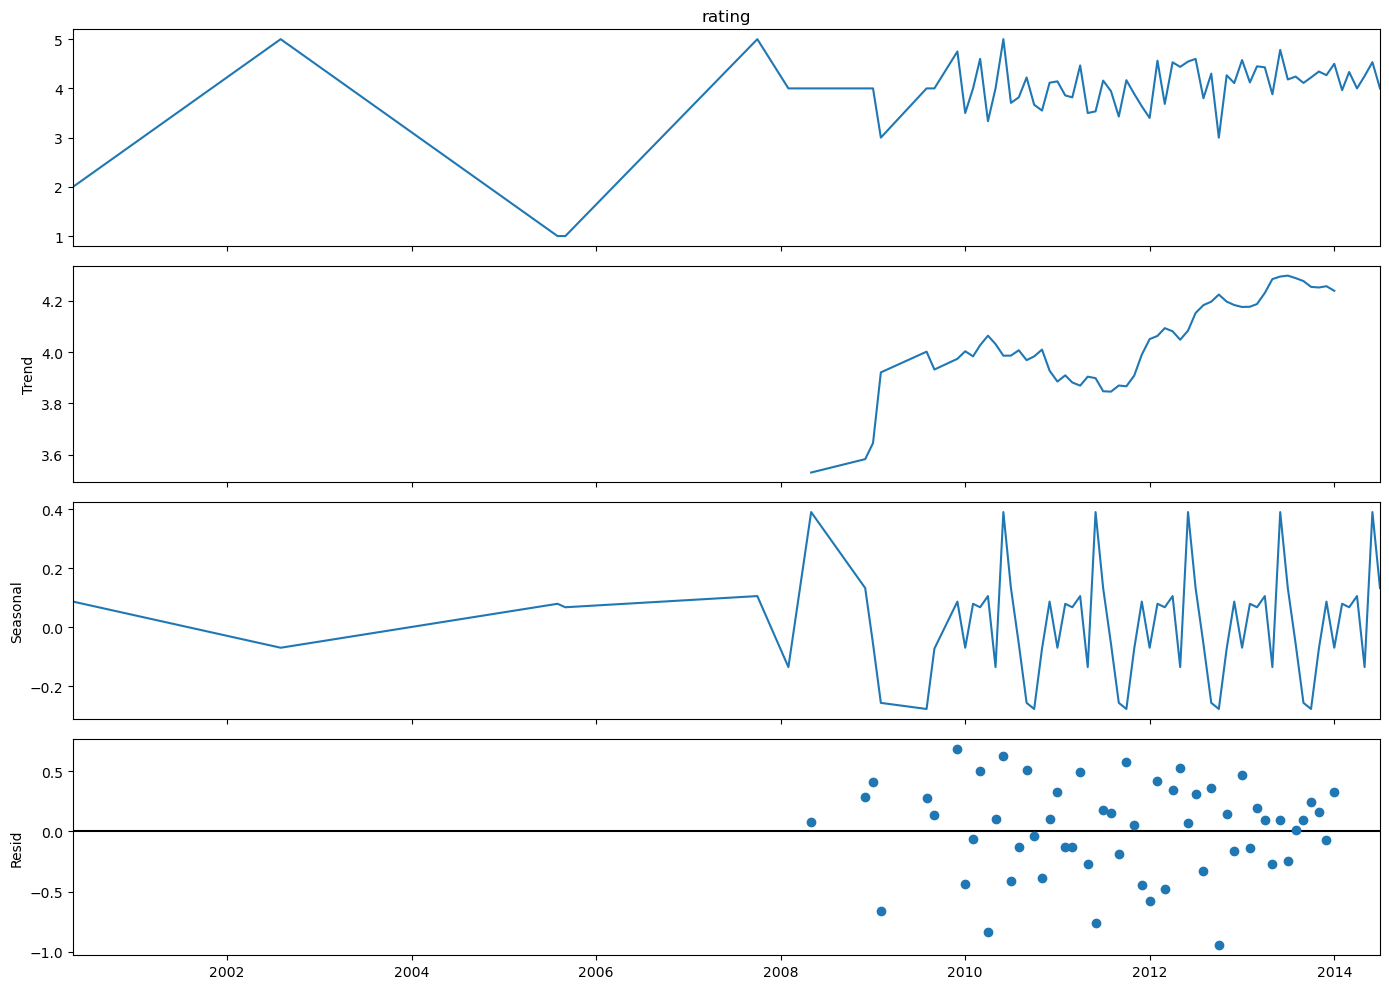

In [467]:
# yearly seasonality using seasonal decomposition
decomposition = seasonal_decompose(
    observed_monthly_rating,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

#### Summary
Trend: The ratings show an overall upward trend over the later part of the series.
Seasonality: The seasonal component shows recurring fluctuations, but a strong 12-month yearly seasonality cannot be confidently established because many calendar months contain no reviews.
Residuals: The residual component contains considerable variation, indicating that factors other than trend and seasonality contribute to changes in monthly ratings.


## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [468]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# TODO: Load the dataset.
# df = ...

# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

# vectorizer = ...
# X_tfidf = ...

# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.

# TODO: One-hot encode the target values if your neural network setup requires it.

# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# model = ...

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

# TODO: Train the model and store the training history.
# history = ...

# TODO: Evaluate the model on the test set.

# TODO: Generate predictions on the test set.

# TODO: Create a classification report and/or confusion matrix to assess performance.

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?


In [493]:
#imports

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
    )
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns


In [470]:
# Load data
df = pd.read_csv("amazon_reviews_lab.csv")

print(df.shape)
df.head()

(997, 9)


,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [471]:
print(df[['review_text', 'rating']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  997 non-null    object
 1   rating       997 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 15.7+ KB
None


In [472]:
#check for missing values
print(df[['review_text', 'rating']].isna().sum())

review_text    0
rating         0
dtype: int64


In [473]:
# X and y
X = df['review_text']
y = df['rating']

In [474]:
print(y.value_counts().sort_index())

rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


The target y has 5 classes so this is a multi class classification hence I will use  the activation function as softmax for the output layer and  the loss function as categorical crossentropy.

In [475]:
#split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [476]:
#Create a stratified validation set
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", len(X_train_final))
print("Validation:", len(X_val))

print("\nTraining class distribution:")
print(y_train_final.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts().sort_index())

Training: 637
Validation: 160

Training class distribution:
rating
1     56
2     30
3     60
4    120
5    371
Name: count, dtype: int64

Validation class distribution:
rating
1    14
2     8
3    15
4    30
5    93
Name: count, dtype: int64


In [477]:
 #Vectorize the text using TF-IDF.

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train_final)
X_test_tfidf = vectorizer.transform(X_test)
X_val_tfidf = vectorizer.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape: (637, 5000)
Testing TF-IDF shape: (200, 5000)
Validation TF-IDF shape: (160, 5000)


To prevent data leakage, I fit_transform the training data but only transformed the test data.

In [478]:
# Encode the target

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_final)
y_test_encoded = label_encoder.transform(y_test)
y_val_encoded = label_encoder.transform(y_val)

print("Encoded classes:", label_encoder.classes_)

y_train_onehot = to_categorical(y_train_encoded, num_classes=5)
y_test_onehot = to_categorical(y_test_encoded, num_classes=5)
y_val_onehot = to_categorical(
    y_val_encoded,
    num_classes=5
)

print("Training target shape:", y_train_onehot.shape)
print("Testing target shape:", y_test_onehot.shape)


Encoded classes: [1 2 3 4 5]
Training target shape: (637, 5)
Testing target shape: (200, 5)


In [479]:
#Prepare TF-IDF Input

X_train_nn = X_train_tfidf.toarray().astype(np.float32)
X_test_nn = X_test_tfidf.toarray().astype(np.float32)

X_val_nn = X_val_tfidf.toarray().astype(np.float32)

print("Training input shape:", X_train_nn.shape)
print("Testing input shape:", X_test_nn.shape)
print("Data type:", X_train_nn.dtype)

Training input shape: (637, 5000)
Testing input shape: (200, 5000)
Data type: float32


In [480]:
class_weights = {
    class_id: np.sqrt(weight)
    for class_id, weight in class_weights.items()
}

print("Moderate class weights:")

for class_id, weight in class_weights.items():
    rating = label_encoder.inverse_transform([class_id])[0]
    print(f"Rating {rating}: {weight:.3f}")

Moderate class weights:
Rating 1: 1.053
Rating 2: 1.094
Rating 3: 1.048
Rating 4: 1.004
Rating 5: 0.935


In [ ]:
#Build the neural network model.

model = keras.Sequential([
    layers.Input(shape=(5000,)),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.40),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.40),

    layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                320064    
                                                                 
 batch_normalization_4 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_5 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dropout_5 (Dropout)         (None, 32)               

A multilayer perceptron was designed with two fully connected hidden layers using ReLU activation. Batch normalization was incorporated to stabilize training, while dropout regularization was used to reduce overfitting. The output layer contains five neurons with softmax activation, corresponding to the five possible rating classes.”

In [482]:
#complie the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [483]:
#Train the model

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    X_train_nn,
    y_train_onehot,
     validation_data=(X_val_nn, y_val_onehot),
    epochs=50,
    batch_size=32,
    #class_weight=class_weights,
    callbacks=[reduce_lr, early_stopping],
    verbose=1
)

Epoch 1/50
20/20 [==============================] - 2s 26ms/step - loss: 2.6267 - accuracy: 0.2355 - val_loss: 1.6961 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 2/50
20/20 [==============================] - 0s 11ms/step - loss: 1.7155 - accuracy: 0.4019 - val_loss: 1.6580 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 3/50
20/20 [==============================] - 0s 11ms/step - loss: 1.3849 - accuracy: 0.5306 - val_loss: 1.6223 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 4/50
20/20 [==============================] - 0s 12ms/step - loss: 1.1421 - accuracy: 0.6452 - val_loss: 1.5860 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 5/50
20/20 [==============================] - 0s 12ms/step - loss: 0.9177 - accuracy: 0.7174 - val_loss: 1.5521 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 6/50
20/20 [==============================] - 0s 11ms/step - loss: 0.7995 - accuracy: 0.7708 - val_loss: 1.5138 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 7/50
20/20 [==============================] - 0s 11ms/step - loss: 0.6

In [484]:
print("Training completed.")
print("Best validation loss:", min(history.history['val_loss']))
print("Best validation accuracy:", max(history.history['val_accuracy']))
print("Epochs trained:", len(history.history['loss']))

Training completed.
Best validation loss: 1.3735826015472412
Best validation accuracy: 0.6000000238418579
Epochs trained: 20


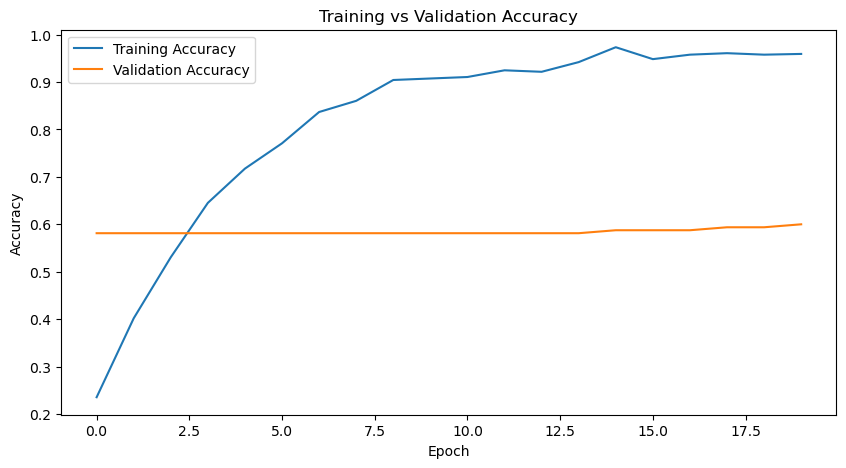

In [485]:
#Plot training vs validation performance

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

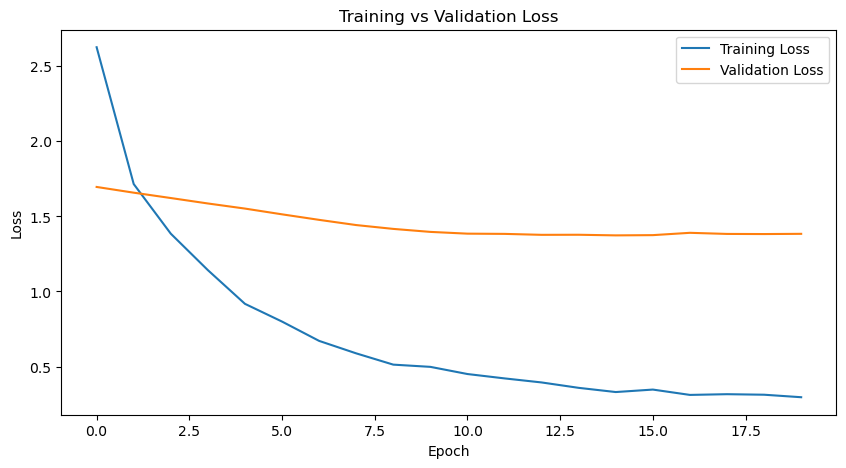

In [486]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [487]:
#Model evaluation

test_loss, test_accuracy = model.evaluate(
    X_test_nn,
    y_test_onehot,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.3770
Test Accuracy: 0.5800


In [488]:
#predict

y_pred_prob = model.predict(X_test_nn, verbose=0)

y_pred_encoded = np.argmax(y_pred_prob, axis=1)

y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("First 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 actual ratings:")
print(y_test.values[:20])

First 20 predictions:
[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]

First 20 actual ratings:
[5 1 4 4 5 1 5 5 5 5 1 4 2 5 1 5 4 5 4 2]


The neural network achieved 58.0% test accuracy however,  the predictions revealed a strong bias toward the majority class rating 5. Therefore, accuracy alone is insufficient for evaluating this model.

In [494]:
#classification report and/or confusion matrix to assess performance.


print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[1, 2, 3, 4, 5],
        zero_division=0
    )
)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nBalanced Accuracy: {balanced_acc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00        38
           5       0.58      1.00      0.73       116

    accuracy                           0.58       200
   macro avg       0.12      0.20      0.15       200
weighted avg       0.34      0.58      0.43       200


Balanced Accuracy: 0.2000


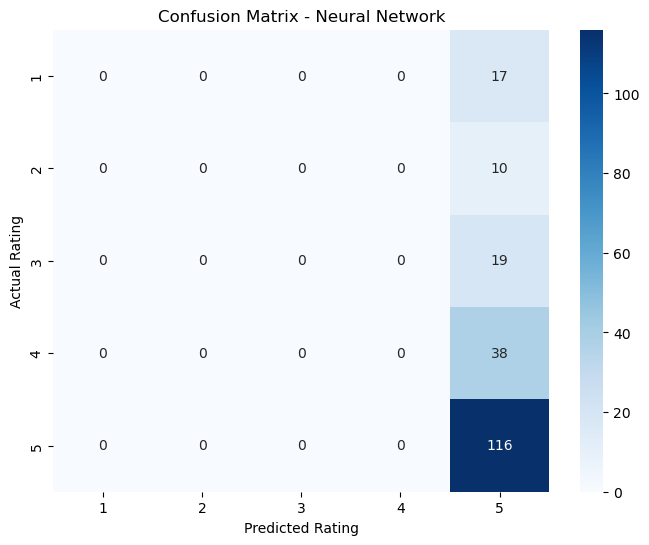

In [490]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

plt.xlabel('Predicted Rating')
plt.ylabel('Actual Rating')
plt.title('Confusion Matrix - Neural Network')

plt.show()

#### Tuned Model

In [491]:
#Tuning Function

def build_model(hp):

    model = keras.Sequential()

    # Input layer
    model.add(layers.Input(shape=(5000,)))

    # First hidden layer
    model.add(
        layers.Dense(
            units=hp.Choice(
                'units_1',
                values=[32, 64, 128]
            ),
            activation='relu',
            kernel_regularizer=regularizers.l2(
                hp.Choice(
                    'l2_rate',
                    values=[0.0001, 0.001]
                )
            )
        )
    )

    model.add(layers.BatchNormalization())

    model.add(
        layers.Dropout(
            hp.Choice(
                'dropout_1',
                values=[0.2, 0.3, 0.4]
            )
        )
    )

    # Second hidden layer
    model.add(
        layers.Dense(
            units=hp.Choice(
                'units_2',
                values=[16, 32, 64]
            ),
            activation='relu',
            kernel_regularizer=regularizers.l2(
                hp.Choice(
                    'l2_rate_2',
                    values=[0.0001, 0.001]
                )
            )
        )
    )

    model.add(layers.BatchNormalization())

    model.add(
        layers.Dropout(
            hp.Choice(
                'dropout_2',
                values=[0.2, 0.3, 0.4]
            )
        )
    )

    # Output layer - 5 rating classes
    model.add(
        layers.Dense(
            5,
            activation='softmax'
        )
    )

    # Learning rate
    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.001, 0.0005]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [497]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=12,
    executions_per_trial=1,
    directory='keras_tuner_results',
    project_name='amazon_reviews_nn',
   
)


tuner.search_space_summary()

Search space summary
Default search space size: 7
units_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
l2_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001], 'ordered': True}
dropout_1 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4], 'ordered': True}
units_2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
l2_rate_2 (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001], 'ordered': True}
dropout_2 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005], 'ordered': True}


In [498]:

# Run Hyperparameter Search


tuner.search(
    X_train_nn,
    y_train_onehot,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ],
    verbose=1
)

Trial 12 Complete [00h 00m 09s]
val_accuracy: 0.5546875

Best val_accuracy So Far: 0.578125
Total elapsed time: 00h 01m 59s


### Conclusion

The neural network model demonstrated evidence of overfitting, as the model performed better on the training data than on the validation and test data. Several techniques were applied to address this issue, including class weights to account for class imbalance, L2 regularization, and Dropout layers to reduce model complexity and improve generalization.

Hyperparameter tuning was also performed to identify a better-performing model configuration. However, the tuning process did not result in a meaningful improvement in performance on the validation and test datasets.

Therefore, despite applying multiple regularization and optimization techniques, the model continued to show signs of overfitting and did not generalize sufficiently well to unseen data. The available dataset and its class imbalance may limit the neural network's ability to generalize effectively. 
